In [1]:
#*** THIS METHOD IS INCORRECT, BECAUSE:
#*** IT ONLY REPRESENTS WHEN GRIDBOXES BECOME OR UNBECOME CLOUDY UPDRAFTS
#*** SO IT REPRESENTS THE ENTRAINMENT/DETRAINMENT OF
#*** CLOUDY UPRAFTS INTO OR OUT OF A REGION

#*** IT IS NOT THE SAME AS ENTRAINMENT OF NEW CLOUDY AIR INTO THOSE UPDRAFT!!!
#*** THESE LIKELY DON'T REALLY REPRESENT ANYTHING PHYSICAL!!!

In [ ]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
res='1km'
Np_str='1e6'

# # dx = 1 km; Np = 1M; Nt = 1 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6_1min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6_1min.nc') #***
# res='1km'
# Np_str='1e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

Top 10 objects with highest memory usage
{'initiate_array_2D': '0.0 MB', 'initiate_array_4D': '0.0 MB', 'Ddt': '0.0 MB', 'Ddz': '0.0 MB', 'Ddz_4DStretch': '0.0 MB', 'Ddy_4D': '0.0 MB', 'Ddx_4d': '0.0 MB', 'Ddz_3D': '0.0 MB', 'Ddy_3D': '0.0 MB', 'Ddx_3D': '0.0 MB'}

0.0 GB in use overall


In [8]:
################################################
#CALCULATING

In [36]:
dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
dir3 = dir2 + 'Project_Algorithms/Entrainment/'
def initiate_array(var_names):
    # Define array dimensions (adjust based on your data)
    t_size = len(data['time'])  # Number of timesteps
    z_size = len(data['zh'])    # Number of vertical levels
    y_size = len(data['yh'])    # Number of y-axis points
    x_size = len(data['xh'])    # Number of x-axis points
    
    with h5py.File(dir3 + '3D_Eulerian_Entrainment2.0'+f'_{res}_{Np_str}'+'.h5', 'a') as f:
        # Check if the dataset 'theta_e' already exists
        if 'conv' not in f:
            # Create a dataset with the full size for all time steps (initially empty)
            for var_name in var_names:
                f.create_dataset(var_name, 
                                 (t_size, z_size, y_size, x_size),  # Full size for all timesteps
                                 maxshape=(None, z_size, y_size, x_size),  # Unlimited timesteps (can grow along time dimension)
                                 dtype='float64', 
                                 chunks=(1, z_size, y_size, x_size))  # Chunks for time axis to allow resizing

            
def add_timestep_at_index(timestep_data, var_name, index):
    with h5py.File(dir3 + '3D_Eulerian_Entrainment2.0'+f'_{res}_{Np_str}'+'.h5', 'a') as f:
        # Access the existing dataset 'theta_e'
        dataset = f[var_name]
        # Assign the new timestep data at the specified index
        dataset[index] = timestep_data

In [75]:
var_names=['E_c','D_c', 
           'E_g','D_g']
initiate_array(var_names)

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(1,len(data['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    
    t_slice=slice(t-1,t+1)

    print('loading in vars')
    w_data=data['winterp'].isel(time=t_slice).data
    qc_data=data['qc'].isel(time=t_slice).data
    qi_data=data['qi'].isel(time=t_slice).data
    qcqi_data=qc_data+qi_data
    rho_data=data['rho'].isel(time=t).data

    print('calculating A_c')
    w_thresh2=0.5
    qcqi_thresh=1e-6
    cond1 = w_data >= w_thresh2
    cond2 = qcqi_data >= qcqi_thresh
    A_c = np.where(cond1 & cond2, 1, 0)

    print('calculating A_g')
    w_thresh1=0.1
    qcqi_thresh=1e-6
    cond1 = w_data >= w_thresh1
    cond2 = qcqi_data < qcqi_thresh
    A_g = np.where(cond1 & cond2, 1, 0)

    H_e = lambda x: 1 * (x > 0) #E HEAVYSIDE
    H_d = lambda x: 1 * (x < 0) #D HEAVYSIDE

    diff_c=(A_c[1:]-A_c[:-1])[0]
    diff_g=(A_g[1:]-A_g[:-1])[0]

    diff_c_e=H_e(diff_c)
    diff_c_d=H_d(diff_c)
    diff_g_e=H_e(diff_g)
    diff_g_d=H_d(diff_g)

    print('calculating Entrainment everywhere')
    E_c = rho_data*diff_c_e
    D_c = rho_data*diff_c_d
    E_g = rho_data*diff_g_e
    D_g = rho_data*diff_g_d

    print('adding Entrainment data timestep to H5 file')
    add_timestep_at_index(E_c, 'E_c', t)
    add_timestep_at_index(D_c, 'D_c', t)
    add_timestep_at_index(E_g, 'E_g', t)
    add_timestep_at_index(D_g, 'D_g', t)

Current time 1
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 2
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 3
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 4
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 5
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 6
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Current time 7
loading in vars
calculating A_c
calculating A_g
calculating Entrainment everywhere
adding Entrainment data timestep to H5 file
Curren

In [ ]:
################################################
#PLOTTING CONTOUR

In [76]:
#READING BACK IN
dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
dir3 = dir2 + 'Project_Algorithms/Entrainment/'
with h5py.File(dir3 + '3D_Eulerian_Entrainment2.0'+f'_{res}_{Np_str}'+'.h5', 'r') as f:
    # Entrainment = f['Entrainment_g'][:]
    E_c = f['E_c'][:]
    D_c = f['D_c'][:]
    E_g = f['E_g'][:]
    D_g = f['D_g'][:]

print('cloudy')
E_c_tz = np.mean(E_c, axis=(2, 3))
E_c_z  = np.mean(E_c, axis=(0, 2, 3))

D_c_tz = np.mean(D_c, axis=(2, 3))
D_c_z  = np.mean(D_c, axis=(0, 2, 3))

print('general')
E_g_tz = np.mean(E_g, axis=(2, 3))
E_g_z  = np.mean(E_g, axis=(0, 2, 3))

D_g_tz = np.mean(D_g, axis=(2, 3))
D_g_z  = np.mean(D_g, axis=(0, 2, 3))

cloudy
general


In [80]:
type2='general'
# type2='cloudy'

dt=data['time'].data[1].item()/1e9
if type2=='general':
    E_tz=E_g_tz.copy()/dt
    E_z=E_g_z.copy()/dt
    
    D_tz=D_g_tz.copy()/dt
    D_z=D_g_z.copy()/dt

elif type2=='cloudy':
    E_tz=E_c_tz.copy()/dt
    E_z=E_c_z.copy()/dt
    
    D_tz=D_c_tz.copy()/dt 
    D_z=D_c_z.copy()/dt

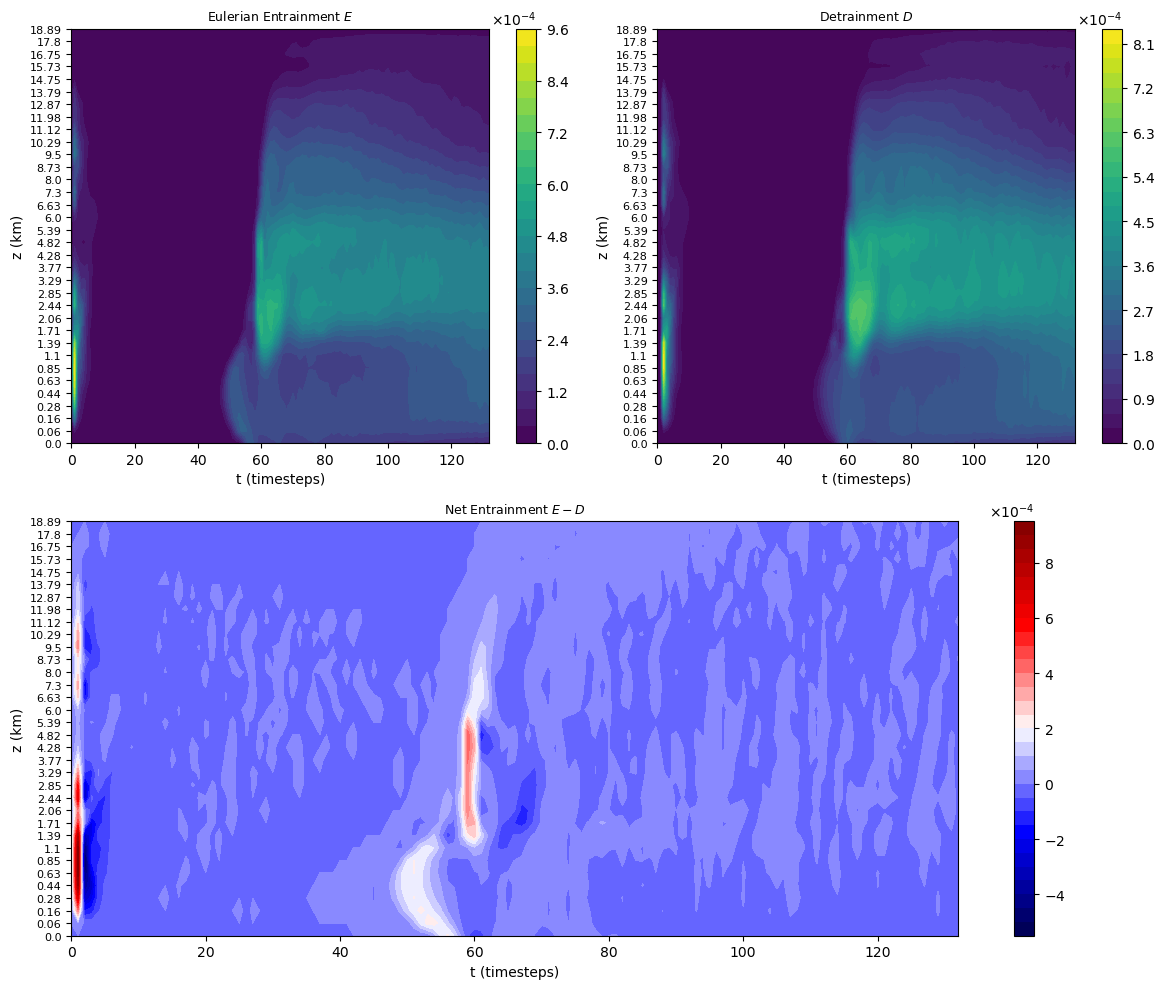

In [81]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels = 29
######

# Assume E_tz and D_tz are already defined

Net_tz = E_tz - D_tz
Nz = len(data['zh'])

# -------- First subplot: E_tz --------
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(E_tz.T, cmap=cmap1, levels=n_levels)
cbar1 = fig.colorbar(contour1, ax=ax1)
apply_scientific_notation_colorbar([cbar1])
ax1.set_yticks(np.arange(Nz))
ax1.set_yticklabels(np.round(data['zf'].values[:Nz], 2), fontsize=8)
ax1.set_ylabel('z (km)')
ax1.set_xlabel('t (timesteps)')
ax1.set_title('Eulerian Entrainment $E$', fontsize=9)

# -------- Second subplot: D_tz --------
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(D_tz.T, cmap=cmap1, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
apply_scientific_notation_colorbar([cbar2])
ax2.set_yticks(np.arange(Nz))
ax2.set_yticklabels(np.round(data['zf'].values[:Nz], 2), fontsize=8)
ax2.set_ylabel('z (km)')
ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment $D$', fontsize=9)

# -------- Third subplot: Net Entrainment (E - D) --------
ax3 = fig.add_subplot(gs[1, :])
contour3 = ax3.contourf(Net_tz.T, cmap=cmap2, levels=n_levels)
cbar3 = fig.colorbar(contour3, ax=ax3)
apply_scientific_notation_colorbar([cbar3])
ax3.set_yticks(np.arange(Nz))
ax3.set_yticklabels(np.round(data['zf'].values[:Nz], 2), fontsize=8)
ax3.set_ylabel('z (km)')
ax3.set_xlabel('t (timesteps)')
ax3.set_title('Net Entrainment $E - D$', fontsize=9)

plt.tight_layout()
plt.show()


Text(0.5, 0, 'Entrainment, M(z) ($kgm^{-3}s^{-1}$)')

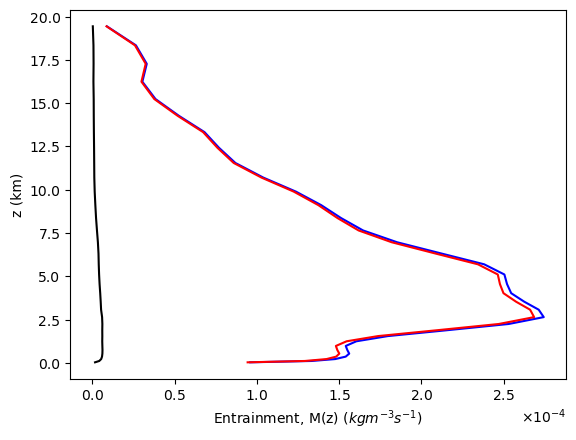

In [84]:
Net_z=E_z-D_z

zh=data['zh'].data
plt.plot(E_z,zh,color='blue')
plt.plot(D_z,zh,color='red')
plt.plot(Net_z,zh,color='black')
ax=plt.gca()
apply_scientific_notation([ax])
plt.ylabel('z (km)');plt.xlabel('Entrainment, M(z) '+r'($kgm^{-3}s^{-1}$)')
